In [1]:
import matplotlib.pyplot as plt

data = {
    1000: {
        'cpu_naive': (33.2368, 0.3547),
        'seq_v2': (2.483647, 0.351183),
        'gpu_v2': (0.631541, 0.007827),
        'gpu_v3': (0.576663, 0.003017),
        'gpu_v4': (0.503096, 0.003686),
        'gpu_v5': (0.478415, 0.000675),
        'gpu_v6': (0.335191, 0.001289),
        'gpu_v7': (2.014243, 0.175766)
    },
    2000: {
        'cpu_naive': (124.8716, 2.3856),
        'seq_v2': (8.966952, 0.113063),
        'gpu_v2': (1.055724, 0.012330),
        'gpu_v3': (0.965481, 0.003421),
        'gpu_v4': (0.647733, 0.000383),
        'gpu_v5': (0.581026, 0.000323),
        'gpu_v6': (0.392224, 0.002281),
        'gpu_v7': (3.312249, 0.032310)
    },
    4000: {
        'cpu_naive': (462.3948, 10.9417),
        'seq_v2': (64.976024, 0.204448),
        'gpu_v2': (2.201429, 0.015430),
        'gpu_v3': (1.971130, 0.000505),
        'gpu_v4': (1.160832, 0.000539),
        'gpu_v5': (0.963155, 0.000299),
        'gpu_v6': (0.607616, 0.000640),
        'gpu_v7': (6.078315, 0.032774)
    },
    8000: {
        'cpu_naive': (1853.4369, 12.4406),
        'seq_v2': (255.498413, 0.343981),
        'gpu_v2': (7.852918, 0.231030),
        'gpu_v3': (7.005298, 0.236785),
        'gpu_v4': (3.141779, 0.023462),
        'gpu_v5': (2.467193, 0.021862),
        'gpu_v6': (0.785364, 0.046525),
        'gpu_v7': (11.619042, 0.031960)
    }
}

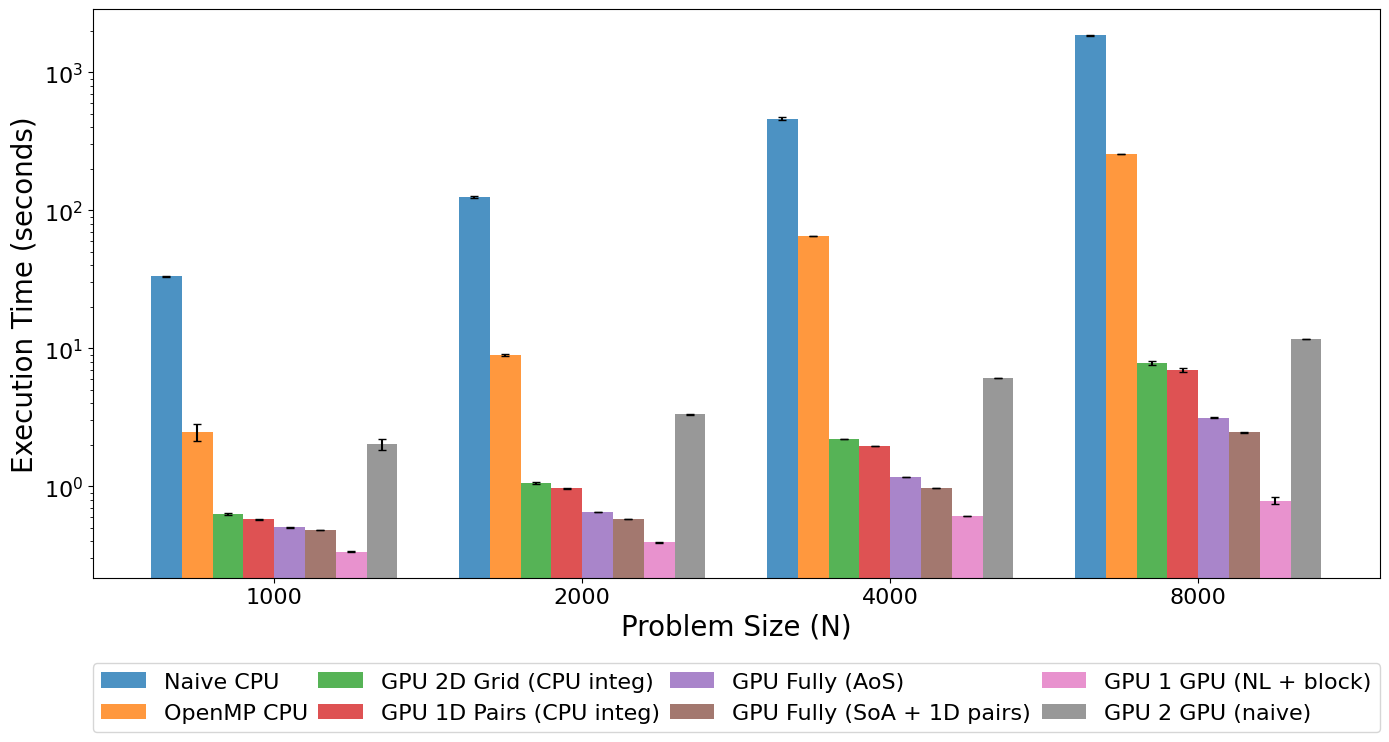

In [5]:
# Mapping system for explainable labels
label_mapping = {
    'cpu_naive': 'Naive CPU',
    'seq_v2': 'OpenMP CPU',
    'gpu_v2': 'GPU 2D Grid (CPU integ)',
    'gpu_v3': 'GPU 1D Pairs (CPU integ)',
    'gpu_v4': 'GPU Fully (AoS)',
    'gpu_v5': 'GPU Fully (SoA + 1D pairs)',
    'gpu_v6': 'GPU 1 GPU (NL + block)',
    'gpu_v7': 'GPU 2 GPU (naive)',
}

# 3. GENERATE HISTOGRAM
n_sizes = sorted(data.keys())
ver_keys = ['cpu_naive', 'seq_v2', 'gpu_v2', 'gpu_v3', 'gpu_v4', 'gpu_v5', 'gpu_v6', 'gpu_v7']

fig, ax = plt.subplots(figsize=(14, 8))
bar_width = 0.1
indices = range(len(n_sizes))

for i, key in enumerate(ver_keys):
    times = [data[n][key][0] for n in n_sizes]
    stds = [data[n][key][1] for n in n_sizes]
    pos = [idx + (i - len(ver_keys)/2) * bar_width + bar_width/2 for idx in indices]
    
    display_label = label_mapping.get(key, key)
    ax.bar(pos, times, bar_width, label=display_label, yerr=stds, capsize=3, alpha=0.8)

# Formatting
ax.set_yscale('log')
ax.set_xticks(indices)
ax.set_xticklabels(n_sizes)
ax.set_xlabel('Problem Size (N)', fontsize=20)
ax.set_ylabel('Execution Time (seconds)', fontsize=20)
ax.tick_params(labelsize=16)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.0, -0.25, 1.0, 0.1),   # x, y, width, height in axes coords
    mode='expand',
    ncol=4,
    fontsize=16,
    borderaxespad=0.0
)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.savefig('performance_variance_plot.png', bbox_inches='tight')
plt.show()

In [8]:
import numpy as np

Best block size: 256  (0.1147 ms/step)


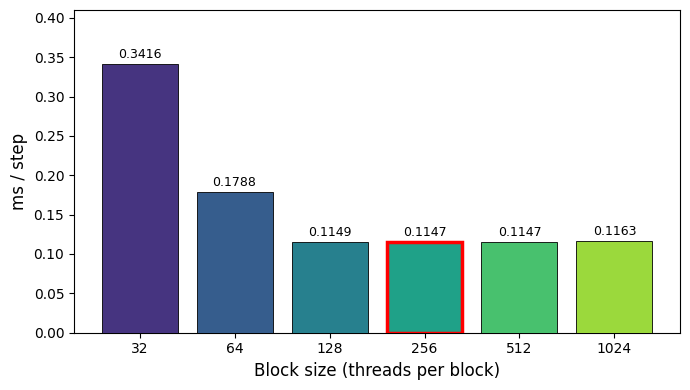

Saved block_size_tuning_N4000.pdf and .png


In [12]:
# ── Data for N=4000 ───────────────────────────────────────────────────────────
block_sizes = [32, 64, 128, 256, 512, 1024]
times       = [0.3416, 0.1788, 0.1149, 0.1147, 0.1147, 0.1163]

best_time = min(times)
best_bs   = block_sizes[times.index(best_time)]
print(f'Best block size: {best_bs}  ({best_time:.4f} ms/step)')
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(block_sizes)))

bars = ax.bar(
    [str(bs) for bs in block_sizes],
    times,
    color=colors,
    edgecolor='black',
    linewidth=0.6,
    zorder=3
)

# Highlight best bar in red
best_idx = times.index(best_time)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2.5)

# Annotate each bar
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f'{t:.4f}',
        ha='center', va='bottom',
        fontsize=9
    )

# Best time reference line

ax.set_xlabel('Block size (threads per block)', fontsize=12)
ax.set_ylabel('ms / step', fontsize=12)
ax.set_ylim(0, max(times) * 1.2)
#ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)


plt.tight_layout()
plt.savefig('block_size_tuning_N4000.pdf', bbox_inches='tight')
plt.savefig('block_size_tuning_N4000.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved block_size_tuning_N4000.pdf and .png')